# DegreeDetailExtract — v3 Anti-Overfitting Training Notebook

**What's new in v3** (vs v2):
- 36 total certificate layout templates (22 original + 6 v2 + **8 new v3**)
- Rich ordinal/textual date formats: *"15th day of June, 2002"*, *"March 11th, 2008"*, etc.
- Optional pass_class — ~30% of generated certs have no class (like real ones)
- 16 prose styles including fully-cursive body, name-at-top, label-value grid, gothic
- **12 training epochs** (was 4) with cosine LR schedule — model actually converges
- Per-epoch checkpoints → resume cell if Colab disconnects
- Per-field accuracy logged every epoch
- 5,500 generated certificates (was 3,000)


## Section 0 — Environment Setup


In [ ]:
# ── Step 1: system fonts ────────────────────────────────────────────────
!apt-get install -y fonts-liberation fonts-dejavu-core -qq

# ── Step 2: tokenizers (pre-built binary wheel — avoids Rust build) ────
# Must be installed BEFORE transformers to prevent source compilation.
!pip install -q --prefer-binary tokenizers

# ── Step 3: transformers + training stack ───────────────────────────────
# No strict version pin on transformers — Colab ships a compatible version.
!pip install -q transformers datasets sentencepiece

# ── Step 4: certificate generation stack ────────────────────────────────
!pip install -q Pillow tqdm faker albumentations opencv-python-headless

# ── Step 5: evaluation tools ────────────────────────────────────────────
!pip install -q editdistance scikit-learn

print('\n✅ All packages installed.')

# Sanity-check critical imports
import transformers, tokenizers, faker, albumentations
print(f'   transformers: {transformers.__version__}')
print(f'   tokenizers  : {tokenizers.__version__}')

Selecting previously unselected package fonts-dejavu-mono.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../fonts-dejavu-mono_2.37-8_all.deb ...
Unpacking fonts-dejavu-mono (2.37-8) ...
Selecting previously unselected package fonts-dejavu-core.
Preparing to unpack .../fonts-dejavu-core_2.37-8_all.deb ...
Unpacking fonts-dejavu-core (2.37-8) ...
Setting up fonts-dejavu-mono (2.37-8) ...
Setting up fonts-dejavu-core (2.37-8) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 38.8 MB/s eta 0:00:00

✅ All packages installed.
   transformers: 5.16.1
   tokenizers  : 0.23.1


In [ ]:
import torch
cuda_ok = torch.cuda.is_available()
print('CUDA:', cuda_ok)
if cuda_ok:
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), 'GB')
else:
    print('WARNING: No GPU — training will be extremely slow!')

CUDA: True
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs('/content/drive/MyDrive/DegreeDetailExtract', exist_ok=True)
print('Google Drive mounted.')

Mounted at /content/drive
Google Drive mounted.


## Section 1 — Clone Repo & Download Fonts


In [ ]:
import os, sys

REPO = '/content/DegreeDetailExtract'
if not os.path.exists(REPO):
    !git clone https://github.com/Vrushti33/DegreeDetailExtract.git {REPO}
else:
    !git -C {REPO} pull

sys.path.insert(0, REPO)

real_certs = os.listdir(f'{REPO}/real_certs')
print(f'Real certs in repo: {len(real_certs)}')
for f in real_certs:
    print(' ', f)

Cloning into '/content/DegreeDetailExtract'...
remote: Enumerating objects: 321, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 321 (delta 41), reused 83 (delta 25), pack-reused 220 (from 1)
Receiving objects: 100% (321/321), 68.20 MiB | 32.12 MiB/s, done.
Resolving deltas: 100% (68/68), done.
Real certs in repo: 24
  images (4).jpg
  1604745185379.jpg
  Degree-certificate-front-back-1-2048.webp
  Degree-Certificate-1-2048.webp
  images (1).jpg
  GHAcvDWXkAECa51.jpg_large
  images (3).jpg
  1.webp
  1740076912714.jpg
  images.jpg
  baea2528-9e8b-4f92-849d-bdc7e819e201-150219003838-conversion-gate02-thumbnail_jpg.rf.ec8462890139d3894524ae4d2203635f.jpg
  Degree-Certificate-Attestation-Services-in-India.webp
  1 (1).webp
  2a7a514f9d69651eb9212da9c7ade66b_jpg.rf.1294f63de510226cd137bfd905c98706.jpg
  images (5).jpg
  UQ-Degree-Cert-1-2048.webp
  Andhra-University-Degree-Certificate_jpg.rf.af5de186ed1b515897302f8e159a76

In [ ]:
# Download calligraphy / formal certificate fonts from Google Fonts (OFL)
# 9 fonts total (5 original + 4 new cursive v4 fonts):
#
#  Great Vibes        — flowing script (student name style 1)
#  Parisienne         — flourished script (student name style 2)  [NEW v4]
#  Allura             — joining script (student name style 3)     [NEW v4]
#  Pinyon Script      — hand-penned calligraphy (style 4)         [NEW v4]
#  Alex Brush         — delicate flowing script (style 5)         [NEW v4]
#  Cinzel [wght]      — university name in engraved Roman capitals
#  IM Fell English    — body prose in antique book type
#  Playfair Display   — section headings (high-contrast serif)
#  UnifrakturMaguntia — optional Old-English blackletter title

from generator.fonts import download_certificate_fonts
download_certificate_fonts('/content/cert_fonts')
print('\n[OK] All 9 certificate fonts ready (5 cursive + 4 formal).')

[fonts] Certificate fonts ready: 11 downloaded, 0 already cached -> /content/cert_fonts

[OK] All 9 certificate fonts ready (5 cursive + 4 formal).


## Section 2 — Generate 5,500 Realistic v4 Certificates

Expected time: **18-28 min** on a T4 GPU Colab session.
Generates 36-template certificates with real paper textures, ordinal dates, and prose.

**v4 IMPORTANT:** `generator/faker_fields.py` was changed to fix closed-vocabulary
memorization (expanded `pass_class` list including "Third Class"/"Third Division"
variants, open-vocabulary university names instead of a fixed list of 85, and
varied `authority_name` formatting instead of always "Title, Name"). You MUST
run the "Force v4 dataset regeneration" cell below before Section 2, otherwise
Colab will just reuse your old, stale v3 dataset from the Drive archive and
none of these fixes will actually reach training.


In [ ]:
!git -C /content/DegreeDetailExtract pull

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 1.29 KiB | 662.00 KiB/s, done.
From https://github.com/Vrushti33/DegreeDetailExtract
   1d47368..c1494a3  main       -> origin/main
Updating 1d47368..c1494a3
Fast-forward
 DegreeDetailExtract_v3.ipynb | 72 ++++++++++++++++++++++++++++++++------------
 1 file changed, 52 insertions(+), 20 deletions(-)


In [ ]:
# ── Force v4 dataset regeneration ──────────────────────────────────────────
import os, shutil

DATASET  = '/content/dataset_v3'
DRIVE    = '/content/drive/MyDrive/DegreeDetailExtract'
OLD_ZIP  = f'{DRIVE}/dataset_v3_archive.zip'

# 1. Delete old local dataset
if os.path.exists(DATASET):
    shutil.rmtree(DATASET)
    print(f'Deleted old dataset: {DATASET}')
os.makedirs(DATASET, exist_ok=True)

# 2. Delete old Drive archive so Section 2 doesn't restore the stale v3 data
if os.path.exists(OLD_ZIP):
    os.remove(OLD_ZIP)
    print(f'Deleted old Drive archive: {OLD_ZIP}')
    print('A fresh v4 archive will be saved after generation.')

print('\nReady. Now run Section 2 Block 1 to generate the v4 dataset.')


Deleted old dataset: /content/dataset_v3

Ready. Now run Section 2 Block 1 to generate the v4 dataset.


In [ ]:
# ── Section 2: Certificate Dataset (4,000 realistic images) ───────────────
import os, shutil

REPO       = '/content/DegreeDetailExtract'
DATASET    = '/content/dataset_v3'
REAL_CERTS = f'{REPO}/real_certs'
DRIVE      = '/content/drive/MyDrive/DegreeDetailExtract'
ZIP_PATH   = f'{DRIVE}/dataset_v3_archive.zip'

os.makedirs(DATASET, exist_ok=True)

# 1. Check if dataset is already in Drive (auto-restore)
meta_train = f'{DATASET}/metadata_train.jsonl'
need_generate = True

if os.path.exists(meta_train):
    count = sum(1 for _ in open(meta_train))
    if count >= 1000:
        print(f'✅ Full dataset already present in {DATASET} ({count:,} records). Skipping generation.')
        need_generate = False

if need_generate and os.path.exists(ZIP_PATH):
    print(f'Extracting dataset archive from Google Drive: {ZIP_PATH}...')
    !unzip -qo "{ZIP_PATH}" -d /content/
    # If extracted to root instead of dataset_v3, ensure structure
    if not os.path.exists(meta_train):
        for root, dirs, files in os.walk('/content'):
            if 'metadata_train.jsonl' in files and root != DATASET:
                for item in os.listdir(root):
                    shutil.move(os.path.join(root, item), DATASET)
                break
    if os.path.exists(meta_train):
        count = sum(1 for _ in open(meta_train))
        if count >= 1000:
            print(f'✅ Extracted {count:,} records from Drive archive.')
            need_generate = False
        else:
            print(f'Archive had only {count} records. Generating fresh full dataset (5,000 certs)...')

# 2. Generate 5,000 realistic certificates if needed (~16-18 min)
if need_generate:
    print('Starting certificate generation (5,000 images)...')
    print('Progress bar will update LIVE below:\n')
    !cd {REPO} && python generate_certificates_v3.py \
        --count 5000 \
        --output_dir {DATASET} \
        --real_certs_dir {REAL_CERTS} \
        --seed 42

    # Automatically back up to Google Drive
    print('\nSaving dataset to Google Drive for future sessions...')
    shutil.make_archive(f'{DRIVE}/dataset_v3_archive', 'zip', DATASET)
    print('✅ Saved dataset_v3_archive.zip to Google Drive.')

# 3. Print final dataset stats
print('\nDataset summary:')
for split in ('train', 'val', 'test'):
    p = f'{DATASET}/metadata_{split}.jsonl'
    n = sum(1 for _ in open(p)) if os.path.exists(p) else 0
    print(f'  {split:5s}: {n:,} records')
print('\n✅ Dataset ready!')

Starting certificate generation (5,000 images)...
Progress bar will update LIVE below:

[realistic_bg] Processing 23 real certificate(s)...
[realistic_bg] Background pool ready: 23 textures.

Generating 5,000 v3 certificates -> /content/dataset_v3
   Train: 4,000  |  Val: 500  |  Test: 500
   Real textures loaded : 23
   Augmentation         : ON (heavy)
   Seed                 : 42

Generating:   0% 0/5000 [00:00<?, ?cert/s]/content/DegreeDetailExtract/generator/renderer_v3.py:103: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Rotate(limit=6, border_mode=0, value=(240, 235, 220), p=0.80),
/content/DegreeDetailExtract/generator/renderer_v3.py:109: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=50, quality_upper=95, p=0.65),
/content/DegreeDetailExtract/generator/renderer_v3.py:113: UserWarning: Argument(s) 'num_shadows_lower, num_shadows_upper' are not valid for transform 

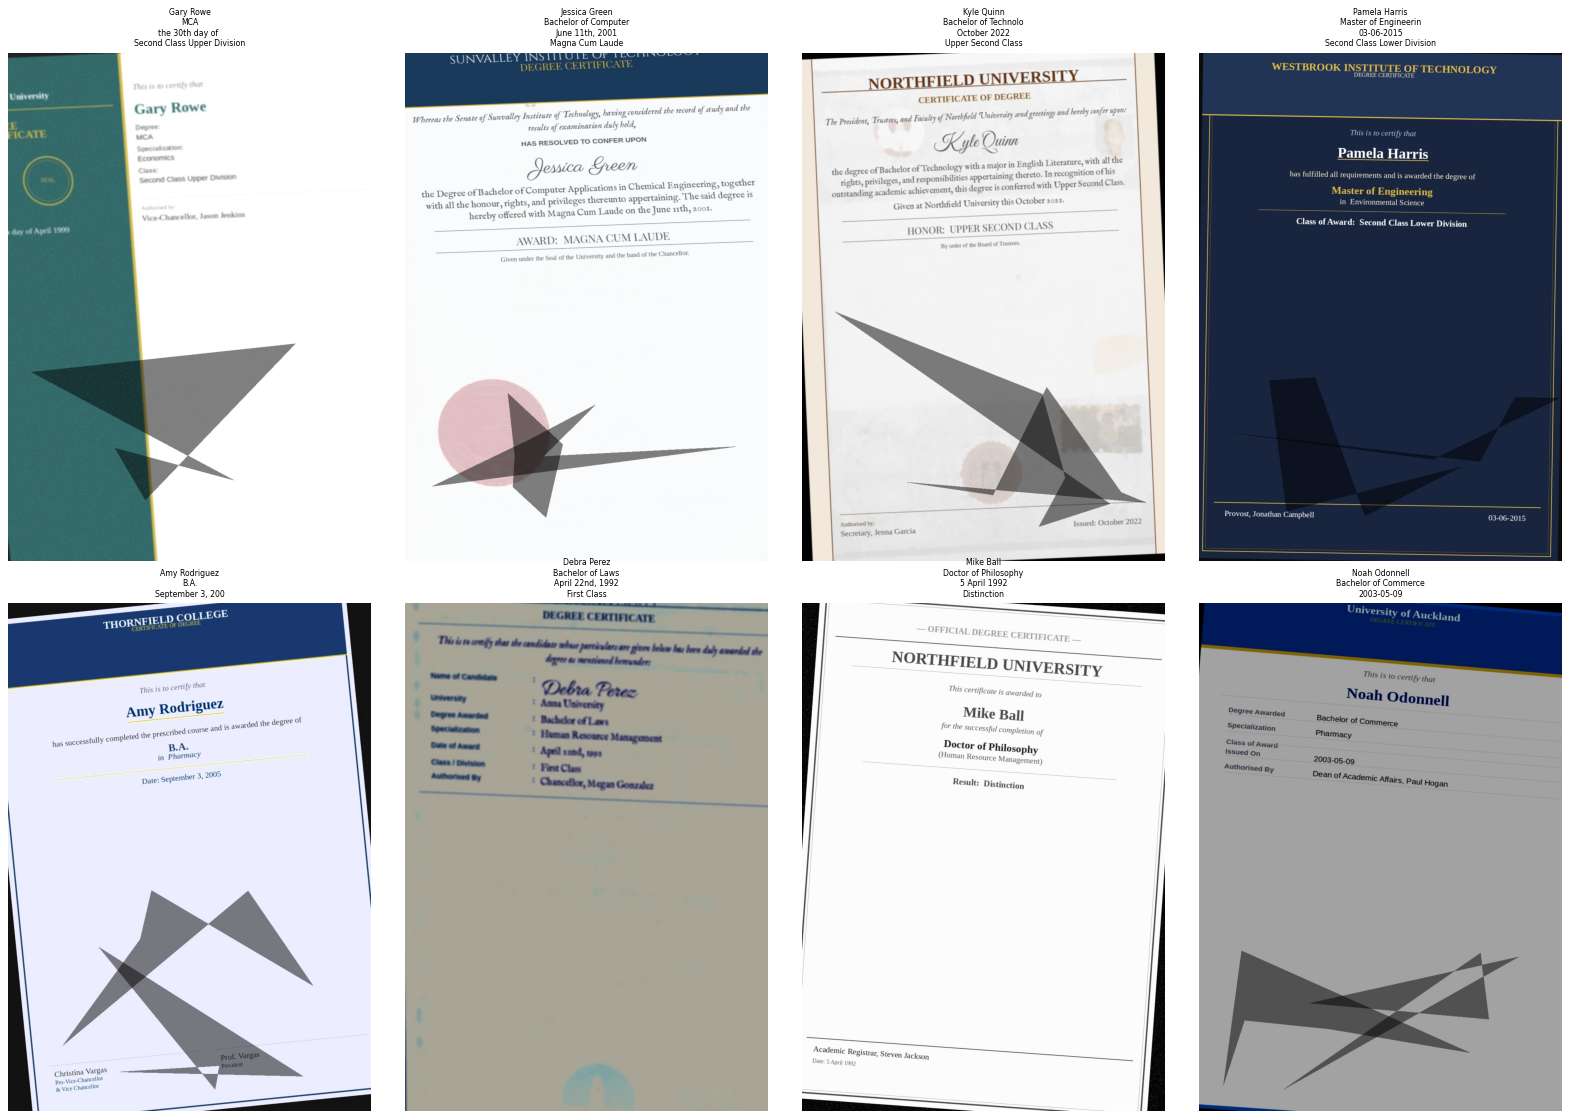


Verify above: real textures, calligraphy fonts, ceremonial prose, ordinal dates, varied spacing.


In [ ]:
# Preview 8 random v3 certificates to visually verify realism
import random, json
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 80

DATASET = '/content/dataset_v3'
with open(f'{DATASET}/metadata_train.jsonl') as f:
    rows = [json.loads(l) for l in f]

samples = random.sample(rows, min(8, len(rows)))
fig, axes = plt.subplots(2, 4, figsize=(20, 14))
for ax, row in zip(axes.flat, samples):
    img = Image.open(f"{DATASET}/{row['file_name']}")
    ax.imshow(img)
    pc = row.get('pass_class', '')
    title = f"{row['student_name'][:18]}\n{row['course_name'][:20]}\n{row['issue_date'][:16]}"
    if pc:
        title += f'\n{pc}'
    ax.set_title(title, fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()
print('\nVerify above: real textures, calligraphy fonts, ceremonial prose, ordinal dates, varied spacing.')

In [ ]:
# Zip and save dataset to Google Drive
import shutil, os
DRIVE = '/content/drive/MyDrive/DegreeDetailExtract'
DATASET = '/content/dataset_v3'
zip_path = f'{DRIVE}/dataset_v3_archive'
print('Zipping dataset...')
shutil.make_archive(zip_path, 'zip', DATASET)
size_gb = os.path.getsize(zip_path + '.zip') / 1e9
print(f'Saved: {zip_path}.zip  ({size_gb:.2f} GB)')

Zipping dataset...
Saved: /content/drive/MyDrive/DegreeDetailExtract/dataset_v3_archive.zip  (0.59 GB)


## Section 3 — Fine-tune Donut (10 Epochs, v4)

> **Expected time**: ~5.5 hrs on T4 GPU for 10 epochs over 5,000 images (~32 min/epoch). Checkpoints saved to Drive every epoch.
>
> Checkpoints are saved to Google Drive **after every epoch**.
> If Colab disconnects, skip to **Section 4 (Resume)** to continue.


In [ ]:
# ── Optimized Model & Processor Setup (960x1280, v4) ─────────────────
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import gc, torch
gc.collect()
torch.cuda.empty_cache()

from transformers import DonutProcessor, VisionEncoderDecoderModel, VisionEncoderDecoderConfig

DRIVE_CKPTS = '/content/drive/MyDrive/DegreeDetailExtract/checkpoints_v3'
os.makedirs(DRIVE_CKPTS, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_ID = 'naver-clova-ix/donut-base'

# 1. Load processor with 960x1280 resolution
processor = DonutProcessor.from_pretrained(MODEL_ID)
processor.image_processor.size = {'height': 960, 'width': 1280}
# v4 fix: do_align_long_axis restored to True. This was disabled in v3 as a
# speed optimisation. Our synthetic canvas is fixed at 1000x1400 (portrait),
# close in ratio to the landscape 960x1280 target, so this specific bug was
# NOT the main cause of the bad real-world output (verified: the uploaded
# real certificate's ratio was 0.707 vs the synthetic canvas's 0.714 - nearly
# identical). But leaving it off is still a real robustness problem: any
# future real upload with an aspect ratio further from 1000x1400 (a
# widescreen scan, a tightly-cropped photo, etc.) will get non-uniformly
# stretched with no warning. Re-enabling this costs a small amount of speed
# and makes inference robust to arbitrary real-world photo orientations.
processor.image_processor.do_align_long_axis = True

# 2. Configure model encoder for 960x1280
config = VisionEncoderDecoderConfig.from_pretrained(MODEL_ID)
config.encoder.image_size = [960, 1280]
config.use_cache = False  # Required for gradient checkpointing

# 3. Add custom schema tokens
NEW_TOKENS = [
    '<s_cert>', '</s_cert>',
    '<s_student_name>',    '</s_student_name>',
    '<s_university_name>', '</s_university_name>',
    '<s_course_name>',     '</s_course_name>',
    '<s_specialization>',  '</s_specialization>',
    '<s_pass_class>',      '</s_pass_class>',
    '<s_authority_name>',  '</s_authority_name>',
    '<s_issue_date>',      '</s_issue_date>',
]
processor.tokenizer.add_special_tokens({'additional_special_tokens': NEW_TOKENS})

# 4. Load model with config
model = VisionEncoderDecoderModel.from_pretrained(
    MODEL_ID,
    config=config,
    ignore_mismatched_sizes=True
)
model.decoder.resize_token_embeddings(len(processor.tokenizer))

model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(['<s_cert>'])[0]
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.convert_tokens_to_ids(['</s_cert>'])[0]

model = model.to(device)
model.gradient_checkpointing_enable()

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Optimized Donut loaded ({n_params:.0f}M params) on {device}')
print(f'   Resolution: 960x1280 | do_align_long_axis: True | Gradient Checkpointing: ENABLED')


In [ ]:
import json, os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch

DATASET = '/content/dataset_v3'

FIELDS = ['student_name', 'university_name', 'course_name',
          'specialization', 'pass_class', 'authority_name', 'issue_date']

def build_target(row):
    """Build Donut target string. Omit value (not the tag) if empty.

    v4 fix: closing tags now correctly match the special tokens registered
    with the tokenizer (</s_student_name> etc.), not a bare </student_name>.
    Previously the target string used a DIFFERENT closing tag than the one
    added to the vocabulary in Section 3's model-setup cell, so the decoder
    never actually learned to use the dedicated closing-tag embeddings — it
    was spelling the closing tag out as ordinary subword tokens instead. This
    still limped along self-consistently (train + eval used the same wrong
    tag), but wasted the vocabulary slots and added avoidable ambiguity to
    what the decoder had to learn.
    """
    parts = ['<s_cert>']
    for f in FIELDS:
        v = row.get(f, '')
        parts.append(f'<s_{f}>{v}</s_{f}>')
    parts.append('</s_cert>')
    return ''.join(parts)


class CertDataset(Dataset):
    def __init__(self, split):
        with open(f'{DATASET}/metadata_{split}.jsonl') as fp:
            self.rows = [json.loads(l) for l in fp]
        self.split = split

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        img = Image.open(f"{DATASET}/{row['file_name']}").convert('RGB')
        pixel_values = processor(
            images=img, return_tensors='pt'
        ).pixel_values.squeeze(0)
        target = build_target(row)
        labels = processor.tokenizer(
            target, add_special_tokens=False,
            max_length=128, truncation=True,
            return_tensors='pt'
        ).input_ids.squeeze(0)
        return pixel_values, labels


def collate_fn(batch):
    pixels, labels_list = zip(*batch)
    pixels = torch.stack(pixels)
    max_len = max(l.size(0) for l in labels_list)
    pad = processor.tokenizer.pad_token_id
    padded = torch.full((len(labels_list), max_len), pad, dtype=torch.long)
    for i, l in enumerate(labels_list):
        padded[i, :l.size(0)] = l
    padded[padded == pad] = -100  # ignore padding in loss
    return pixels, padded


train_ds = CertDataset('train')
val_ds   = CertDataset('val')
test_ds  = CertDataset('test')

BATCH = 4
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                      num_workers=2, collate_fn=collate_fn, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                      num_workers=2, collate_fn=collate_fn, pin_memory=True)

print(f'Train: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_ds):,}')
print(f'Batch size: {BATCH} | Batches per epoch: {len(train_dl):,}')


In [ ]:
# ─────────────────────────────────────────────────────────────────────
#  Fine-Tuning: 10 Epochs | FP16 AMP | Batch 4 x GradAccum 2
#  Target:  ~32 min/epoch  (~5.5 hrs total, checkpoints saved every epoch)
#  Resume:  If Colab disconnects, use Section 4 to continue training.
# ─────────────────────────────────────────────────────────────────────
import os, math, json, sys, gc, torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# Release any lingering memory from previous runs
sys.last_traceback = None
sys.last_value = None
gc.collect()
torch.cuda.empty_cache()

NUM_EPOCHS       = 10         # 10 epochs for robust layout-invariant learning
LR               = 3e-5
WARMUP_STEPS     = 200        # warmup over ~1/5 of epoch 1
GRAD_ACCUM       = 2          # effective batch = 4 * 2 = 8
MAX_GRAD_NORM    = 1.0
LOG_EVERY        = 50
DRIVE_CKPTS      = '/content/drive/MyDrive/DegreeDetailExtract/checkpoints_v3'

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_dl) * NUM_EPOCHS // GRAD_ACCUM
scheduler = CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=5e-7)
scaler = torch.amp.GradScaler('cuda')

step_global = 0
def get_lr():
    if step_global < WARMUP_STEPS:
        return LR * step_global / max(1, WARMUP_STEPS)
    return scheduler.get_last_lr()[0]


def save_checkpoint(epoch, val_loss):
    ckpt_dir = f'{DRIVE_CKPTS}/epoch_{epoch:02d}'
    os.makedirs(ckpt_dir, exist_ok=True)
    model.save_pretrained(ckpt_dir)
    processor.save_pretrained(ckpt_dir)
    meta = {'epoch': epoch, 'val_loss': val_loss, 'step': step_global, 'lr': get_lr()}
    with open(f'{ckpt_dir}/train_meta.json', 'w') as fp:
        json.dump(meta, fp, indent=2)
    print(f'  [ckpt] Saved epoch {epoch} -> {ckpt_dir} (val_loss={val_loss:.4f})')


print(f'Starting fast v3 training: {NUM_EPOCHS} epochs')
print(f'  Batch size: {BATCH} | Grad Accum: {GRAD_ACCUM} (Effective batch: {BATCH * GRAD_ACCUM})')
print(f'  Total update steps: ~{total_steps:,}')
print(f'  Checkpoints: {DRIVE_CKPTS}\n')

history = []
best_val_loss = float('inf')

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\n=== Epoch {epoch}/{NUM_EPOCHS} ===')
    model.train()
    train_loss = 0.0
    optimizer.zero_grad()

    for batch_idx, (pixels, labels) in enumerate(train_dl):
        pixels = pixels.to(device)
        labels = labels.to(device)

        if step_global < WARMUP_STEPS:
            for pg in optimizer.param_groups:
                pg['lr'] = LR * step_global / max(1, WARMUP_STEPS)

        # Fast FP16 forward pass
        with torch.amp.autocast('cuda'):
            out  = model(pixel_values=pixels, labels=labels)
            loss = out.loss / GRAD_ACCUM

        scaler.scale(loss).backward()
        train_loss += loss.item() * GRAD_ACCUM

        if (batch_idx + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            if step_global >= WARMUP_STEPS:
                scheduler.step()
            optimizer.zero_grad()
            step_global += 1

        if (batch_idx + 1) % LOG_EVERY == 0:
            avg = train_loss / (batch_idx + 1)
            print(f'  step {step_global:5d} | batch {batch_idx+1}/{len(train_dl)} | loss={avg:.4f} | lr={get_lr():.2e}')

    avg_train_loss = train_loss / len(train_dl)

    # Fast Validation loss (teacher-forced, takes ~20 seconds)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for pixels, labels in val_dl:
            pixels, labels = pixels.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                val_loss += model(pixel_values=pixels, labels=labels).loss.item()
    val_loss /= len(val_dl)

    print(f'  🏁 Epoch {epoch}: train_loss={avg_train_loss:.4f} | val_loss={val_loss:.4f}')

    history.append({'epoch': epoch, 'train_loss': avg_train_loss, 'val_loss': val_loss})
    save_checkpoint(epoch, val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_dir = f'{DRIVE_CKPTS}/best'
        import shutil
        if os.path.exists(best_dir): shutil.rmtree(best_dir)
        shutil.copytree(f'{DRIVE_CKPTS}/epoch_{epoch:02d}', best_dir)
        print(f'  ⭐ [best] New best val_loss={best_val_loss:.4f} saved.')

print('\n🎉 Training complete! Checkpoints saved to Google Drive.')

Starting fast v3 training: 10 epochs
  Batch size: 4 | Grad Accum: 2 (Effective batch: 8)
  Total update steps: ~5,000
  Checkpoints: /content/drive/MyDrive/DegreeDetailExtract/checkpoints_v3


=== Epoch 1/10 ===
  step    25 | batch 50/1000 | loss=0.3115 | lr=3.75e-06
  step    50 | batch 100/1000 | loss=0.2968 | lr=7.50e-06
  step    75 | batch 150/1000 | loss=0.2922 | lr=1.13e-05
  step   100 | batch 200/1000 | loss=0.2776 | lr=1.50e-05
  step   125 | batch 250/1000 | loss=0.2665 | lr=1.88e-05
  step   150 | batch 300/1000 | loss=0.2586 | lr=2.25e-05
  step   175 | batch 350/1000 | loss=0.2516 | lr=2.63e-05
  step   200 | batch 400/1000 | loss=0.2464 | lr=3.00e-05
  step   225 | batch 450/1000 | loss=0.2382 | lr=2.98e-05
  step   250 | batch 500/1000 | loss=0.2313 | lr=2.98e-05
  step   275 | batch 550/1000 | loss=0.2254 | lr=2.98e-05
  step   300 | batch 600/1000 | loss=0.2201 | lr=2.98e-05
  step   325 | batch 650/1000 | loss=0.2143 | lr=2.98e-05
  step   350 | batch 700/1000 | lo

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [ckpt] Saved epoch 1 -> /content/drive/MyDrive/DegreeDetailExtract/checkpoints_v3/epoch_01 (val_loss=0.1247)
  ⭐ [best] New best val_loss=0.1247 saved.

=== Epoch 2/10 ===
  step   525 | batch 50/1000 | loss=0.1004 | lr=2.95e-05
  step   550 | batch 100/1000 | loss=0.1088 | lr=2.95e-05
  step   575 | batch 150/1000 | loss=0.1027 | lr=2.94e-05
  step   600 | batch 200/1000 | loss=0.1076 | lr=2.94e-05
  step   625 | batch 250/1000 | loss=0.1047 | lr=2.93e-05
  step   650 | batch 300/1000 | loss=0.1044 | lr=2.93e-05
  step   675 | batch 350/1000 | loss=0.1033 | lr=2.92e-05
  step   700 | batch 400/1000 | loss=0.1032 | lr=2.91e-05
  step   725 | batch 450/1000 | loss=0.1039 | lr=2.91e-05
  step   750 | batch 500/1000 | loss=0.1019 | lr=2.90e-05
  step   775 | batch 550/1000 | loss=0.1008 | lr=2.89e-05
  step   800 | batch 600/1000 | loss=0.0992 | lr=2.88e-05
  step   825 | batch 650/1000 | loss=0.0980 | lr=2.87e-05
  step   850 | batch 700/1000 | loss=0.0963 | lr=2.86e-05
  step   875 | 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [ckpt] Saved epoch 2 -> /content/drive/MyDrive/DegreeDetailExtract/checkpoints_v3/epoch_02 (val_loss=0.1029)
  ⭐ [best] New best val_loss=0.1029 saved.

=== Epoch 3/10 ===
  step  1025 | batch 50/1000 | loss=0.0457 | lr=2.79e-05
  step  1050 | batch 100/1000 | loss=0.0549 | lr=2.78e-05
  step  1075 | batch 150/1000 | loss=0.0601 | lr=2.77e-05
  step  1100 | batch 200/1000 | loss=0.0610 | lr=2.76e-05
  step  1125 | batch 250/1000 | loss=0.0614 | lr=2.74e-05
  step  1150 | batch 300/1000 | loss=0.0601 | lr=2.73e-05
  step  1175 | batch 350/1000 | loss=0.0613 | lr=2.72e-05
  step  1200 | batch 400/1000 | loss=0.0596 | lr=2.70e-05
  step  1225 | batch 450/1000 | loss=0.0608 | lr=2.69e-05
  step  1250 | batch 500/1000 | loss=0.0629 | lr=2.68e-05
  step  1275 | batch 550/1000 | loss=0.0636 | lr=2.66e-05
  step  1300 | batch 600/1000 | loss=0.0643 | lr=2.65e-05
  step  1325 | batch 650/1000 | loss=0.0637 | lr=2.63e-05
  step  1350 | batch 700/1000 | loss=0.0641 | lr=2.62e-05
  step  1375 | 

...

  [ckpt] Saved epoch 4 -> /content/drive/MyDrive/DegreeDetailExtract/checkpoints_v3/epoch_04 (val_loss=0.0960)

=== Epoch 5/10 ===
  step  2025 | batch 50/1000 | loss=0.0591 | lr=2.12e-05
  step  2050 | batch 100/1000 | loss=0.0512 | lr=2.10e-05
  step  2075 | batch 150/1000 | loss=0.0468 | lr=2.08e-05
  step  2100 | batch 200/1000 | loss=0.0466 | lr=2.06e-05
  step  2125 | batch 250/1000 | loss=0.0446 | lr=2.04e-05
  step  2150 | batch 300/1000 | loss=0.0427 | lr=2.01e-05
  step  2175 | batch 350/1000 | loss=0.0416 | lr=1.99e-05
  step  2200 | batch 400/1000 | loss=0.0412 | lr=1.97e-05
  step  2225 | batch 450/1000 | loss=0.0413 | lr=1.95e-05
  step  2250 | batch 500/1000 | loss=0.0415 | lr=1.93e-05
  step  2275 | batch 550/1000 | loss=0.0424 | lr=1.90e-05
  step  2300 | batch 600/1000 | loss=0.0424 | lr=1.88e-05
  step  2325 | batch 650/1000 | loss=0.0422 | lr=1.86e-05
  step  2350 | batch 700/1000 | loss=0.0425 | lr=1.84e-05
  step  2375 | batch 750/1000 | loss=0.0431 | lr=1.82e-05


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [ckpt] Saved epoch 5 -> /content/drive/MyDrive/DegreeDetailExtract/checkpoints_v3/epoch_05 (val_loss=0.0942)

=== Epoch 6/10 ===
  step  2525 | batch 50/1000 | loss=0.0464 | lr=1.68e-05
  step  2550 | batch 100/1000 | loss=0.0387 | lr=1.66e-05
  step  2575 | batch 150/1000 | loss=0.0352 | lr=1.63e-05
  step  2600 | batch 200/1000 | loss=0.0373 | lr=1.61e-05
  step  2625 | batch 250/1000 | loss=0.0370 | lr=1.59e-05
  step  2650 | batch 300/1000 | loss=0.0349 | lr=1.56e-05
  step  2675 | batch 350/1000 | loss=0.0342 | lr=1.54e-05
  step  2700 | batch 400/1000 | loss=0.0342 | lr=1.52e-05
  step  2725 | batch 450/1000 | loss=0.0342 | lr=1.49e-05
  step  2750 | batch 500/1000 | loss=0.0342 | lr=1.47e-05
  step  2775 | batch 550/1000 | loss=0.0343 | lr=1.45e-05
  step  2800 | batch 600/1000 | loss=0.0341 | lr=1.43e-05
  step  2825 | batch 650/1000 | loss=0.0339 | lr=1.40e-05
  step  2850 | batch 700/1000 | loss=0.0333 | lr=1.38e-05
  step  2875 | batch 750/1000 | loss=0.0327 | lr=1.36e-05


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [ckpt] Saved epoch 6 -> /content/drive/MyDrive/DegreeDetailExtract/checkpoints_v3/epoch_06 (val_loss=0.0982)

=== Epoch 7/10 ===
  step  3025 | batch 50/1000 | loss=0.0252 | lr=1.22e-05
  step  3050 | batch 100/1000 | loss=0.0290 | lr=1.20e-05
  step  3075 | batch 150/1000 | loss=0.0279 | lr=1.17e-05
  step  3100 | batch 200/1000 | loss=0.0273 | lr=1.15e-05
  step  3125 | batch 250/1000 | loss=0.0267 | lr=1.13e-05
  step  3150 | batch 300/1000 | loss=0.0246 | lr=1.11e-05
  step  3175 | batch 350/1000 | loss=0.0248 | lr=1.09e-05
  step  3200 | batch 400/1000 | loss=0.0259 | lr=1.06e-05
  step  3225 | batch 450/1000 | loss=0.0264 | lr=1.04e-05
  step  3250 | batch 500/1000 | loss=0.0266 | lr=1.02e-05
  step  3275 | batch 550/1000 | loss=0.0273 | lr=9.99e-06
  step  3300 | batch 600/1000 | loss=0.0272 | lr=9.77e-06
  step  3325 | batch 650/1000 | loss=0.0273 | lr=9.56e-06
  step  3350 | batch 700/1000 | loss=0.0269 | lr=9.35e-06
  step  3375 | batch 750/1000 | loss=0.0265 | lr=9.14e-06


## Section 4 — Resume Training (if Colab Disconnected)

Run this cell to resume from the **latest checkpoint** saved to Drive.
Skip this section entirely if training completed normally in Section 3.


In [ ]:
# ── Section 4: Resume Training from Saved Checkpoint (Self-Contained) ───────
# This cell can be run directly after any Colab timeout / disconnection / restart.
# It handles everything: Drive check, dataset restore (if needed), loading the
# latest checkpoint (e.g. Epoch 6), and continuing training to Epoch 10.
# ─────────────────────────────────────────────────────────────────────────────
import os, sys, gc, json, glob, shutil, tempfile, math, torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from transformers import DonutProcessor, VisionEncoderDecoderModel
from PIL import Image

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# ── 1. Check / Mount Google Drive ────────────────────────────────────────────
DRIVE_BASE  = '/content/drive/MyDrive/DegreeDetailExtract'
DRIVE_CKPTS = f'{DRIVE_BASE}/checkpoints_v3'
ZIP_PATH    = f'{DRIVE_BASE}/dataset_v3_archive.zip'

if not os.path.exists('/content/drive/MyDrive'):
    print("Google Drive not detected. Attempting to mount...")
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception as e:
        raise RuntimeError(
            "Please mount Google Drive first (run Section 0) so checkpoints can be read!"
        ) from e

if not os.path.exists(DRIVE_CKPTS):
    raise RuntimeError(
        f"Checkpoint directory not found: {DRIVE_CKPTS}\n"
        "Please make sure Google Drive is mounted and previous checkpoints exist."
    )

# ── 2. Check / Restore Dataset in /content/dataset_v3 ────────────────────────
DATASET = '/content/dataset_v3'
meta_train = f'{DATASET}/metadata_train.jsonl'
need_dataset = not os.path.exists(meta_train) or (sum(1 for _ in open(meta_train)) < 1000)

if need_dataset:
    print(f"Dataset not found at {DATASET}. Restoring from Google Drive archive...")
    if not os.path.exists(ZIP_PATH):
        raise RuntimeError(
            f"Dataset archive not found at: {ZIP_PATH}\n"
            "Cannot train without dataset. Run Section 2 to create/restore the dataset."
        )
    import subprocess
    os.makedirs(DATASET, exist_ok=True)
    TMP = tempfile.mkdtemp(prefix='cert_extract_', dir='/content')
    try:
        print(f"  Extracting {ZIP_PATH} ...")
        subprocess.run(['unzip', '-qo', ZIP_PATH, '-d', TMP], check=True)
        found_root = None
        for root, dirs, files in os.walk(TMP):
            dirs[:] = [d for d in dirs if not d.startswith('drive')]
            if 'metadata_train.jsonl' in files:
                found_root = root
                break
        if found_root:
            for item in os.listdir(found_root):
                src_p = os.path.join(found_root, item)
                dst_p = os.path.join(DATASET, item)
                if os.path.exists(dst_p):
                    if os.path.isdir(dst_p): shutil.rmtree(dst_p)
                    else: os.remove(dst_p)
                shutil.move(src_p, DATASET)
            print(f"  Dataset restored successfully to {DATASET}")
        else:
            raise RuntimeError(f"Could not find metadata_train.jsonl inside {ZIP_PATH}!")
    finally:
        if os.path.exists(TMP):
            shutil.rmtree(TMP, ignore_errors=True)
else:
    count = sum(1 for _ in open(meta_train))
    print(f"Dataset ready at {DATASET} ({count:,} train samples).")

# ── 3. Find Latest Checkpoint ────────────────────────────────────────────────
epoch_dirs = sorted(glob.glob(f'{DRIVE_CKPTS}/epoch_*'))
if not epoch_dirs:
    raise RuntimeError(
        f"No checkpoints found at: {DRIVE_CKPTS}\n"
        "Run Section 3 first or verify Drive path."
    )

latest_dir = epoch_dirs[-1]
meta_file = f'{latest_dir}/train_meta.json'
if not os.path.exists(meta_file):
    raise RuntimeError(f"Metadata file missing in {latest_dir}!")

with open(meta_file) as fp:
    meta = json.load(fp)

completed_epochs = meta['epoch']
start_epoch      = completed_epochs + 1
step_global      = meta['step']
last_lr          = meta.get('lr', 1.2e-5)
best_val_loss    = meta.get('val_loss', float('inf'))

print(f"\nFound latest checkpoint: {latest_dir}")
print(f"  Completed Epochs : {completed_epochs}")
print(f"  Resuming at Epoch: {start_epoch}")
print(f"  Global Step      : {step_global}")
print(f"  Learning Rate    : {last_lr:.2e}")
print(f"  Previous Val Loss: {best_val_loss:.4f}")

NUM_EPOCHS = 10
if start_epoch > NUM_EPOCHS:
    print(f"\nAll {NUM_EPOCHS} epochs are already finished! You can proceed to Section 5 (Evaluation).")
    raise SystemExit(0)

# ── 4. Load Model & Processor from Latest Checkpoint ─────────────────────────
gc.collect()
torch.cuda.empty_cache()
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

print(f"\nLoading model & processor from {latest_dir} ...")
processor = DonutProcessor.from_pretrained(latest_dir)
model     = VisionEncoderDecoderModel.from_pretrained(latest_dir).to(device)
model.config.use_cache = False
model.gradient_checkpointing_enable()
print("Model loaded & gradient checkpointing enabled.")

# ── 5. Rebuild Dataset & DataLoaders ──────────────────────────────────────────
FIELDS = ['student_name', 'university_name', 'course_name',
          'specialization', 'pass_class', 'authority_name', 'issue_date']

def build_target(row):
    parts = ['<s_cert>']
    for f in FIELDS:
        v = row.get(f, '')
        if f == 'pass_class' and not v:
            parts.append('<s_pass_class></s_pass_class>')
        else:
            parts.append(f'<s_{f}>{v}</{f}>')
    parts.append('</s_cert>')
    return ''.join(parts)

class CertDataset(Dataset):
    def __init__(self, split):
        with open(f'{DATASET}/metadata_{split}.jsonl') as fp:
            self.rows = [json.loads(l) for l in fp]
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, idx):
        row = self.rows[idx]
        img = Image.open(f"{DATASET}/{row['file_name']}").convert('RGB')
        pv  = processor(images=img, return_tensors='pt').pixel_values.squeeze(0)
        tgt = build_target(row)
        lbl = processor.tokenizer(
            tgt, add_special_tokens=False,
            max_length=128, truncation=True,
            return_tensors='pt'
        ).input_ids.squeeze(0)
        return pv, lbl

def collate_fn(batch):
    pixels, labels_list = zip(*batch)
    pixels = torch.stack(pixels)
    max_len = max(l.size(0) for l in labels_list)
    pad = processor.tokenizer.pad_token_id
    padded = torch.full((len(labels_list), max_len), pad, dtype=torch.long)
    for i, l in enumerate(labels_list):
        padded[i, :l.size(0)] = l
    padded[padded == pad] = -100
    return pixels, padded

BATCH = 4
train_ds = CertDataset('train')
val_ds   = CertDataset('val')
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                      num_workers=2, collate_fn=collate_fn, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                      num_workers=2, collate_fn=collate_fn, pin_memory=True)

print(f"Dataset ready: {len(train_ds):,} train | {len(val_ds):,} val")
print(f"Batches per epoch: {len(train_dl):,}")

# ── 6. Setup Optimizer, Scheduler, and Scaler ────────────────────────────────
GRAD_ACCUM       = 2
MAX_GRAD_NORM    = 1.0
LOG_EVERY        = 50
remaining_epochs = NUM_EPOCHS - completed_epochs
total_remaining_steps = len(train_dl) * remaining_epochs // GRAD_ACCUM

optimizer = AdamW(model.parameters(), lr=last_lr, weight_decay=0.01)
scheduler = CosineAnnealingLR(optimizer, T_max=max(1, total_remaining_steps), eta_min=5e-7)
scaler    = torch.amp.GradScaler('cuda')

def save_checkpoint(epoch, val_loss):
    ckpt_dir = f'{DRIVE_CKPTS}/epoch_{epoch:02d}'
    os.makedirs(ckpt_dir, exist_ok=True)
    model.save_pretrained(ckpt_dir)
    processor.save_pretrained(ckpt_dir)
    meta_data = {
        'epoch': epoch,
        'val_loss': val_loss,
        'step': step_global,
        'lr': scheduler.get_last_lr()[0]
    }
    with open(f'{ckpt_dir}/train_meta.json', 'w') as fp:
        json.dump(meta_data, fp, indent=2)
    print(f'  [ckpt] Saved epoch {epoch} -> {ckpt_dir} (val_loss={val_loss:.4f})')

# ── 7. Resumed Training Loop ──────────────────────────────────────────────────
print(f"\nResuming training: Epochs {start_epoch} -> {NUM_EPOCHS}")
print(f"Remaining epochs: {remaining_epochs} (~{32 * remaining_epochs} minutes total)\n")

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    print(f"\n=== Epoch {epoch}/{NUM_EPOCHS} (resumed) ===")
    model.train()
    train_loss = 0.0
    optimizer.zero_grad()

    for batch_idx, (pixels, labels) in enumerate(train_dl):
        pixels, labels = pixels.to(device), labels.to(device)

        with torch.amp.autocast('cuda'):
            out  = model(pixel_values=pixels, labels=labels)
            loss = out.loss / GRAD_ACCUM

        scaler.scale(loss).backward()
        train_loss += loss.item() * GRAD_ACCUM

        if (batch_idx + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
            step_global += 1

        if (batch_idx + 1) % LOG_EVERY == 0:
            avg = train_loss / (batch_idx + 1)
            cur_lr = scheduler.get_last_lr()[0]
            print(f"  step {step_global:5d} | batch {batch_idx+1}/{len(train_dl)} | loss={avg:.4f} | lr={cur_lr:.2e}")

    avg_train_loss = train_loss / len(train_dl)

    # Validation pass
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for pixels, labels in val_dl:
            pixels, labels = pixels.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                val_loss += model(pixel_values=pixels, labels=labels).loss.item()
    val_loss /= len(val_dl)

    print(f"  Epoch {epoch}: train_loss={avg_train_loss:.4f} | val_loss={val_loss:.4f}")
    save_checkpoint(epoch, val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_dir = f'{DRIVE_CKPTS}/best'
        if os.path.exists(best_dir):
            shutil.rmtree(best_dir)
        shutil.copytree(f'{DRIVE_CKPTS}/epoch_{epoch:02d}', best_dir)
        print(f"  * [best] New best val_loss={best_val_loss:.4f} saved to {best_dir}")

print(f"\nTraining complete! All epochs {start_epoch} to {NUM_EPOCHS} finished.")
print(f"Best model saved at: {DRIVE_CKPTS}/best")


Using device: cuda
Google Drive not detected. Attempting to mount...
Mounted at /content/drive
Dataset not found at /content/dataset_v3. Restoring from Google Drive archive...
  Extracting /content/drive/MyDrive/DegreeDetailExtract/dataset_v3_archive.zip ...
  Dataset restored successfully to /content/dataset_v3

Found latest checkpoint: /content/drive/MyDrive/DegreeDetailExtract/checkpoints_v3/epoch_06
  Completed Epochs : 6
  Resuming at Epoch: 7
  Global Step      : 3000
  Learning Rate    : 1.24e-05
  Previous Val Loss: 0.0982

Loading model & processor from /content/drive/MyDrive/DegreeDetailExtract/checkpoints_v3/epoch_06 ...


Loading weights:   0%|          | 0/483 [00:00<?, ?it/s]

Model loaded & gradient checkpointing enabled.
Dataset ready: 4,000 train | 500 val
Batches per epoch: 1,000

Resuming training: Epochs 7 -> 10
Remaining epochs: 4 (~128 minutes total)


=== Epoch 7/10 (resumed) ===


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


  step  3025 | batch 50/1000 | loss=0.0267 | lr=1.24e-05
  step  3050 | batch 100/1000 | loss=0.0271 | lr=1.24e-05
  step  3075 | batch 150/1000 | loss=0.0255 | lr=1.24e-05
  step  3100 | batch 200/1000 | loss=0.0274 | lr=1.24e-05
  step  3125 | batch 250/1000 | loss=0.0269 | lr=1.23e-05
  step  3150 | batch 300/1000 | loss=0.0271 | lr=1.23e-05
  step  3175 | batch 350/1000 | loss=0.0270 | lr=1.22e-05
  step  3200 | batch 400/1000 | loss=0.0263 | lr=1.21e-05
  step  3225 | batch 450/1000 | loss=0.0261 | lr=1.21e-05
  step  3250 | batch 500/1000 | loss=0.0262 | lr=1.20e-05
  step  3275 | batch 550/1000 | loss=0.0272 | lr=1.19e-05
  step  3300 | batch 600/1000 | loss=0.0270 | lr=1.18e-05
  step  3325 | batch 650/1000 | loss=0.0263 | lr=1.17e-05
  step  3350 | batch 700/1000 | loss=0.0268 | lr=1.15e-05
  step  3375 | batch 750/1000 | loss=0.0266 | lr=1.14e-05
  step  3400 | batch 800/1000 | loss=0.0272 | lr=1.13e-05
  step  3425 | batch 850/1000 | loss=0.0270 | lr=1.11e-05
  step  3450 | 

...

  [ckpt] Saved epoch 8 -> /content/drive/MyDrive/DegreeDetailExtract/checkpoints_v3/epoch_08 (val_loss=0.1113)

=== Epoch 9/10 (resumed) ===
  step  4025 | batch 50/1000 | loss=0.0154 | lr=6.23e-06
  step  4050 | batch 100/1000 | loss=0.0166 | lr=5.99e-06
  step  4075 | batch 150/1000 | loss=0.0145 | lr=5.76e-06
  step  4100 | batch 200/1000 | loss=0.0150 | lr=5.53e-06
  step  4125 | batch 250/1000 | loss=0.0145 | lr=5.30e-06
  step  4150 | batch 300/1000 | loss=0.0145 | lr=5.07e-06
  step  4175 | batch 350/1000 | loss=0.0144 | lr=4.84e-06
  step  4200 | batch 400/1000 | loss=0.0149 | lr=4.62e-06
  step  4225 | batch 450/1000 | loss=0.0149 | lr=4.40e-06
  step  4250 | batch 500/1000 | loss=0.0151 | lr=4.18e-06
  step  4275 | batch 550/1000 | loss=0.0153 | lr=3.97e-06
  step  4300 | batch 600/1000 | loss=0.0150 | lr=3.76e-06
  step  4325 | batch 650/1000 | loss=0.0154 | lr=3.55e-06
  step  4350 | batch 700/1000 | loss=0.0151 | lr=3.35e-06
  step  4375 | batch 750/1000 | loss=0.0147 | lr

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [ckpt] Saved epoch 9 -> /content/drive/MyDrive/DegreeDetailExtract/checkpoints_v3/epoch_09 (val_loss=0.1185)

=== Epoch 10/10 (resumed) ===
  step  4525 | batch 50/1000 | loss=0.0099 | lr=2.08e-06
  step  4550 | batch 100/1000 | loss=0.0125 | lr=1.93e-06
  step  4575 | batch 150/1000 | loss=0.0118 | lr=1.78e-06
  step  4600 | batch 200/1000 | loss=0.0115 | lr=1.64e-06
  step  4625 | batch 250/1000 | loss=0.0116 | lr=1.50e-06
  step  4650 | batch 300/1000 | loss=0.0115 | lr=1.38e-06
  step  4675 | batch 350/1000 | loss=0.0118 | lr=1.26e-06
  step  4700 | batch 400/1000 | loss=0.0117 | lr=1.15e-06
  step  4725 | batch 450/1000 | loss=0.0121 | lr=1.05e-06
  step  4750 | batch 500/1000 | loss=0.0122 | lr=9.54e-07
  step  4775 | batch 550/1000 | loss=0.0123 | lr=8.69e-07
  step  4800 | batch 600/1000 | loss=0.0122 | lr=7.92e-07
  step  4825 | batch 650/1000 | loss=0.0122 | lr=7.24e-07
  step  4850 | batch 700/1000 | loss=0.0120 | lr=6.65e-07
  step  4875 | batch 750/1000 | loss=0.0121 | l

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [ckpt] Saved epoch 10 -> /content/drive/MyDrive/DegreeDetailExtract/checkpoints_v3/epoch_10 (val_loss=0.1211)

Training complete! All epochs 7 to 10 finished.
Best model saved at: /content/drive/MyDrive/DegreeDetailExtract/checkpoints_v3/best


## Section 5 — Evaluation


In [2]:
import os, glob, shutil, tempfile, torch
from transformers import DonutProcessor, VisionEncoderDecoderModel

# ── 1. Check / Mount Google Drive ────────────────────────────────────────────
if not os.path.exists('/content/drive/MyDrive'):
    print("Google Drive is not mounted! Mounting now...")
    from google.colab import drive
    drive.mount('/content/drive')

DRIVE_BASE  = '/content/drive/MyDrive/DegreeDetailExtract'
DRIVE_CKPTS = f'{DRIVE_BASE}/checkpoints_v3'
BEST        = f'{DRIVE_CKPTS}/best'
ZIP_PATH    = f'{DRIVE_BASE}/dataset_v3_archive.zip'
DATASET     = '/content/dataset_v3'
device      = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── 2. Ensure test dataset is available locally for evaluation ────────────────
if not os.path.exists(f'{DATASET}/metadata_test.jsonl'):
    if os.path.exists(ZIP_PATH):
        print(f"Dataset not found in /content. Restoring from {ZIP_PATH} ...")
        import subprocess
        os.makedirs(DATASET, exist_ok=True)
        TMP = tempfile.mkdtemp(prefix='eval_cert_', dir='/content')
        try:
            subprocess.run(['unzip', '-qo', ZIP_PATH, '-d', TMP], check=True)
            for root, dirs, files in os.walk(TMP):
                dirs[:] = [d for d in dirs if not d.startswith('drive')]
                if 'metadata_test.jsonl' in files:
                    for item in os.listdir(root):
                        dst = os.path.join(DATASET, item)
                        if os.path.exists(dst):
                            if os.path.isdir(dst): shutil.rmtree(dst)
                            else: os.remove(dst)
                        shutil.move(os.path.join(root, item), DATASET)
                    break
            print("✅ Dataset restored successfully.")
        finally:
            if os.path.exists(TMP): shutil.rmtree(TMP, ignore_errors=True)
    else:
        print("Notice: metadata_test.jsonl not found, but continuing to model loading.")

# ── 3. Determine which checkpoint directory to load ──────────────────────────
load_dir = None
if os.path.exists(BEST):
    load_dir = BEST
    print(f"Found 'best' model checkpoint: {BEST}")
else:
    epoch_dirs = sorted(glob.glob(f'{DRIVE_CKPTS}/epoch_*'))
    if epoch_dirs:
        load_dir = epoch_dirs[-1]
        print(f"'best' folder not found yet. Using latest epoch checkpoint: {load_dir}")
    else:
        raise FileNotFoundError(
            f"No checkpoints found at '{DRIVE_CKPTS}'!\n"
            "Please ensure training has saved at least one epoch to Google Drive."
        )

# ── 4. Load processor and model ──────────────────────────────────────────────
print(f"Loading Donut model & processor from: {load_dir} ...")
processor = DonutProcessor.from_pretrained(load_dir)
model     = VisionEncoderDecoderModel.from_pretrained(load_dir).to(device)
model.eval()
print(f"✅ Model successfully loaded on {device} from: {load_dir}")


Google Drive is not mounted! Mounting now...
Mounted at /content/drive
Dataset not found in /content. Restoring from /content/drive/MyDrive/DegreeDetailExtract/dataset_v3_archive.zip ...
✅ Dataset restored successfully.
Found 'best' model checkpoint: /content/drive/MyDrive/DegreeDetailExtract/checkpoints_v3/best
Loading Donut model & processor from: /content/drive/MyDrive/DegreeDetailExtract/checkpoints_v3/best ...


Loading weights:   0%|          | 0/483 [00:00<?, ?it/s]

✅ Model successfully loaded on cuda from: /content/drive/MyDrive/DegreeDetailExtract/checkpoints_v3/best


In [ ]:
import json, re, editdistance
from PIL import Image
import torch

DATASET = '/content/dataset_v3'
FIELDS  = ['student_name', 'university_name', 'course_name',
           'specialization', 'pass_class', 'authority_name', 'issue_date']

with open(f'{DATASET}/metadata_test.jsonl') as fp:
    test_rows = [json.loads(l) for l in fp]

MAX_EVAL = min(200, len(test_rows))
field_exact  = {f: 0 for f in FIELDS}
field_cer    = {f: [] for f in FIELDS}  # character error rate
field_total  = {f: 0 for f in FIELDS}

task_prompt = processor.tokenizer.decode(
    [model.config.decoder_start_token_id], skip_special_tokens=False)

for row in test_rows[:MAX_EVAL]:
    img = Image.open(f"{DATASET}/{row['file_name']}").convert('RGB')
    pixels = processor(images=img, return_tensors='pt').pixel_values.to(device)
    dec_ids = processor.tokenizer(
        task_prompt, add_special_tokens=False, return_tensors='pt'
    ).input_ids.to(device)
    with torch.no_grad():
        out = model.generate(pixel_values=pixels, decoder_input_ids=dec_ids,
                             max_new_tokens=128, early_stopping=True)
    pred_str = processor.tokenizer.decode(out[0], skip_special_tokens=False)

    for f in FIELDS:
        gt  = str(row.get(f, ''))
        # v4 fix: closing tag now correctly includes the s_ prefix, matching
        # the special tokens registered in Section 3 (and matching what
        # build_target() now actually generates).
        m   = re.search(fr'<s_{f}>(.*?)</s_{f}>', pred_str, re.DOTALL)
        pred = m.group(1).strip() if m else ''
        field_total[f] += 1
        if pred.lower() == gt.lower():
            field_exact[f] += 1
        cer = editdistance.eval(pred, gt) / max(len(gt), 1)
        field_cer[f].append(cer)

print(f'Evaluation on {MAX_EVAL} SYNTHETIC test certificates')
print('NOTE: this only measures in-distribution accuracy. It does NOT tell you')
print('how well the model performs on real photographed certificates - see')
print('Section 8 for that. Do not report this table alone as your accuracy.\n')
print(f'{"Field":<25} {"Exact %":>8} {"Avg CER":>8}')
print('-' * 45)
for f in FIELDS:
    exact_pct = field_exact[f] / max(1, field_total[f]) * 100
    avg_cer   = sum(field_cer[f]) / max(1, len(field_cer[f])) * 100
    bar = '|' * int(exact_pct / 5)
    print(f'{f:<25} {exact_pct:7.1f}%  {avg_cer:7.1f}%   {bar}')


In [ ]:
# Show 3 test examples: predicted fields vs ground truth
import random, re, json
from PIL import Image
import matplotlib.pyplot as plt

DATASET = '/content/dataset_v3'
FIELDS  = ['student_name', 'university_name', 'course_name',
           'specialization', 'pass_class', 'authority_name', 'issue_date']

with open(f'{DATASET}/metadata_test.jsonl') as fp:
    test_rows = [json.loads(l) for l in fp]

samples = random.sample(test_rows, 3)
fig, axes = plt.subplots(1, 3, figsize=(18, 9))

task_prompt = processor.tokenizer.decode(
    [model.config.decoder_start_token_id], skip_special_tokens=False)

for ax, row in zip(axes, samples):
    img = Image.open(f"{DATASET}/{row['file_name']}").convert('RGB')
    pixels = processor(images=img, return_tensors='pt').pixel_values.to(device)
    dec_ids = processor.tokenizer(task_prompt, add_special_tokens=False,
                                   return_tensors='pt').input_ids.to(device)
    with torch.no_grad():
        out = model.generate(pixel_values=pixels, decoder_input_ids=dec_ids,
                             max_new_tokens=128, early_stopping=True)
    pred_str = processor.tokenizer.decode(out[0], skip_special_tokens=False)

    annotation = ''
    for f in FIELDS:
        gt = str(row.get(f, ''))
        m  = re.search(fr'<s_{f}>(.*?)</s_{f}>', pred_str, re.DOTALL)
        pred = m.group(1).strip() if m else 'MISSING'
        icon = 'OK' if pred.lower() == gt.lower() else 'X'
        annotation += f'[{icon}] {f[:14]}: {pred[:22]}\n'

    ax.imshow(img)
    ax.set_title(annotation, fontsize=6.5, family='monospace', loc='left')
    ax.axis('off')

plt.tight_layout()
plt.show()


## Section 6 — Inference on a Real Certificate


In [1]:
from google.colab import files
uploaded = files.upload()
real_cert_path = list(uploaded.keys())[0]
print('Uploaded:', real_cert_path)

Saving images (6).jpg to images (6).jpg
Uploaded: images (6).jpg


In [ ]:
import os, glob, shutil, tempfile, torch
from transformers import DonutProcessor, VisionEncoderDecoderModel

# -- 1. Check / Mount Google Drive --------------------------------------------
if not os.path.exists('/content/drive/MyDrive'):
    print("Google Drive is not mounted! Mounting now...")
    from google.colab import drive
    drive.mount('/content/drive')

DRIVE_BASE  = '/content/drive/MyDrive/DegreeDetailExtract'
DRIVE_CKPTS = f'{DRIVE_BASE}/checkpoints_v3'
BEST        = f'{DRIVE_CKPTS}/best'
# v4: prefer the real-data fine-tuned checkpoint from Section 7 if it exists
BEST_REAL_FT = f'{DRIVE_BASE}/checkpoints_v3_real_ft/best'
ZIP_PATH    = f'{DRIVE_BASE}/dataset_v3_archive.zip'
DATASET     = '/content/dataset_v3'
device      = 'cuda' if torch.cuda.is_available() else 'cpu'

# -- 2. Ensure test dataset is available locally for evaluation --------------
if not os.path.exists(f'{DATASET}/metadata_test.jsonl'):
    if os.path.exists(ZIP_PATH):
        print(f"Dataset not found in /content. Restoring from {ZIP_PATH} ...")
        import subprocess
        os.makedirs(DATASET, exist_ok=True)
        TMP = tempfile.mkdtemp(prefix='eval_cert_', dir='/content')
        try:
            subprocess.run(['unzip', '-qo', ZIP_PATH, '-d', TMP], check=True)
            for root, dirs, files in os.walk(TMP):
                dirs[:] = [d for d in dirs if not d.startswith('drive')]
                if 'metadata_test.jsonl' in files:
                    for item in os.listdir(root):
                        dst = os.path.join(DATASET, item)
                        if os.path.exists(dst):
                            if os.path.isdir(dst): shutil.rmtree(dst)
                            else: os.remove(dst)
                        shutil.move(os.path.join(root, item), DATASET)
                    break
            print("Dataset restored successfully.")
        finally:
            if os.path.exists(TMP): shutil.rmtree(TMP, ignore_errors=True)
    else:
        print("Notice: metadata_test.jsonl not found, but continuing to model loading.")

# -- 3. Determine which checkpoint directory to load --------------------------
if os.path.exists(BEST_REAL_FT):
    load_dir = BEST_REAL_FT
    print(f"Found real-data fine-tuned checkpoint: {BEST_REAL_FT}")
elif os.path.exists(BEST):
    load_dir = BEST
    print(f"Found 'best' synthetic-only checkpoint: {BEST}")
else:
    epoch_dirs = sorted(glob.glob(f'{DRIVE_CKPTS}/epoch_*'))
    if epoch_dirs:
        load_dir = epoch_dirs[-1]
        print(f"'best' folder not found yet. Using latest epoch checkpoint: {load_dir}")
    else:
        raise FileNotFoundError(
            f"No checkpoints found at '{DRIVE_CKPTS}'!\n"
            "Please ensure training has saved at least one epoch to Google Drive."
        )

# -- 4. Load processor and model ----------------------------------------------
print(f"Loading Donut model & processor from: {load_dir} ...")
processor = DonutProcessor.from_pretrained(load_dir)
model     = VisionEncoderDecoderModel.from_pretrained(load_dir).to(device)
model.eval()
print(f"Model successfully loaded on {device} from: {load_dir}")


import re, json
from PIL import Image
import torch

FIELDS = ['student_name', 'university_name', 'course_name',
          'specialization', 'pass_class', 'authority_name', 'issue_date']

img = Image.open(real_cert_path).convert('RGB')
pixels = processor(images=img, return_tensors='pt').pixel_values.to(device)

task_prompt = processor.tokenizer.decode(
    [model.config.decoder_start_token_id], skip_special_tokens=False)
dec_ids = processor.tokenizer(task_prompt, add_special_tokens=False,
                               return_tensors='pt').input_ids.to(device)

with torch.no_grad():
    out = model.generate(pixel_values=pixels, decoder_input_ids=dec_ids,
                         max_new_tokens=128, early_stopping=True)

pred_str = processor.tokenizer.decode(out[0], skip_special_tokens=False)

result = {}
for f in FIELDS:
    # v4 fix: closing tag matches the registered special token.
    m = re.search(fr'<s_{f}>(.*?)</s_{f}>', pred_str, re.DOTALL)
    result[f] = m.group(1).strip() if m else ''

print(json.dumps(result, indent=2, ensure_ascii=False))

missing = [f for f in FIELDS if f not in result or not result[f]]
if not missing:
    print('\nAll 7 fields extracted.')
else:
    print('\nMissing fields:', missing)


## Section 7 — Real-Certificate Domain Adaptation (NEW in v4)

**Why this section exists:** every certificate the model has trained on so far
is synthetic. Section 5's metrics only measure accuracy on more synthetic
data from the same generator, so they cannot tell you how the model performs
on an actual photographed certificate. Section 6 is where that gap became
visible.

This section fine-tunes the trained model on a **small set of real, manually
labeled certificates** at a low learning rate, continuing from your best
synthetic checkpoint. This is standard practice for document-AI models:
synthetic data teaches the model the *task* (broad coverage, cheap to
generate at scale); a small amount of real data teaches it what *real*
certificates actually look like (fonts, seals, scan artifacts, photography).
Even 20-40 labeled real images meaningfully closes this gap.

### What you need to do first (outside this notebook)
1. Collect 15-30+ real degree certificate images (as varied in
   university/layout as you can get).
2. For each one, write down the 7 field values by hand.
3. Upload the images to
   `/content/drive/MyDrive/DegreeDetailExtract/real_labeled/images/`
   and create
   `/content/drive/MyDrive/DegreeDetailExtract/real_labeled/metadata.jsonl`
   with one JSON object per line, matching the same schema as your synthetic
   dataset:
   ```json
   {"file_name": "cert_001.jpg", "student_name": "Nishad T", "university_name": "University of Calicut", "course_name": "Bachelor of Commerce", "specialization": "", "pass_class": "Third Class", "authority_name": "Vice Chancellor", "issue_date": "23/09/2015"}
   ```
   Leave a field as `""` if it genuinely isn't present/legible - do not guess.
4. Keep this file honest and consistent: e.g., decide *now* how you will
   record multi-part results (this course's certificate lists three separate
   "Third Class" results per part) - a reasonable convention is to record the
   overall/final class if the certificate states one, otherwise the last
   part's class. Whatever you choose, apply it the same way to every row.
5. Split your rows into `real_train` (~80%) and `real_eval` (~20%). Do
   **not** train on `real_eval` rows - Section 8 uses them to give you an
   honest accuracy number.


In [ ]:
# ── Load and split the small real-labeled dataset ────────────────────────────
import os, json, random

REAL_BASE = '/content/drive/MyDrive/DegreeDetailExtract/real_labeled'
REAL_META = f'{REAL_BASE}/metadata.jsonl'

if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

if not os.path.exists(REAL_META):
    raise FileNotFoundError(
        f"Could not find {REAL_META}.\n"
        "Follow the instructions above: upload real certificate images and "
        "a metadata.jsonl file to this path before running this section."
    )

with open(REAL_META) as fp:
    real_rows = [json.loads(l) for l in fp if l.strip()]

print(f'Loaded {len(real_rows)} real labeled certificates.')
if len(real_rows) < 10:
    print('WARNING: fewer than 10 real examples. Domain adaptation will still '
          'help, but results will be noisy - label more if you can.')

random.seed(42)
random.shuffle(real_rows)
split_idx = max(1, int(len(real_rows) * 0.8))
real_train_rows = real_rows[:split_idx]
real_eval_rows  = real_rows[split_idx:] or real_rows[-2:]  # ensure eval isn't empty

os.makedirs('/content/real_labeled', exist_ok=True)
with open('/content/real_labeled/real_train.jsonl', 'w') as fp:
    for r in real_train_rows:
        fp.write(json.dumps(r) + '\n')
with open('/content/real_labeled/real_eval.jsonl', 'w') as fp:
    for r in real_eval_rows:
        fp.write(json.dumps(r) + '\n')

print(f'real_train: {len(real_train_rows)}  |  real_eval: {len(real_eval_rows)} (held out, never trained on)')


In [ ]:
# ── Fine-tune the best synthetic checkpoint on real data (domain adaptation) ─
import os, json, gc, torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel

DRIVE_BASE    = '/content/drive/MyDrive/DegreeDetailExtract'
SYN_BEST      = f'{DRIVE_BASE}/checkpoints_v3/best'
REAL_FT_CKPTS = f'{DRIVE_BASE}/checkpoints_v3_real_ft'
os.makedirs(REAL_FT_CKPTS, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
FIELDS = ['student_name', 'university_name', 'course_name',
          'specialization', 'pass_class', 'authority_name', 'issue_date']

def build_target(row):
    parts = ['<s_cert>']
    for f in FIELDS:
        parts.append(f'<s_{f}>{row.get(f, "")}</s_{f}>')
    parts.append('</s_cert>')
    return ''.join(parts)

print(f'Loading synthetic-trained checkpoint from {SYN_BEST} ...')
processor = DonutProcessor.from_pretrained(SYN_BEST)
model = VisionEncoderDecoderModel.from_pretrained(SYN_BEST).to(device)
model.config.use_cache = False
model.gradient_checkpointing_enable()

class RealCertDataset(Dataset):
    def __init__(self, jsonl_path, img_dir):
        with open(jsonl_path) as fp:
            self.rows = [json.loads(l) for l in fp]
        self.img_dir = img_dir

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        img = Image.open(f"{self.img_dir}/{row['file_name']}").convert('RGB')
        pixel_values = processor(images=img, return_tensors='pt').pixel_values.squeeze(0)
        target = build_target(row)
        labels = processor.tokenizer(
            target, add_special_tokens=False, max_length=128,
            truncation=True, return_tensors='pt'
        ).input_ids.squeeze(0)
        return pixel_values, labels

def collate_fn(batch):
    pixels, labels_list = zip(*batch)
    pixels = torch.stack(pixels)
    max_len = max(l.size(0) for l in labels_list)
    pad = processor.tokenizer.pad_token_id
    padded = torch.full((len(labels_list), max_len), pad, dtype=torch.long)
    for i, l in enumerate(labels_list):
        padded[i, :l.size(0)] = l
    padded[padded == pad] = -100
    return pixels, padded

IMG_DIR = f'{REAL_BASE}/images'
real_train_ds = RealCertDataset('/content/real_labeled/real_train.jsonl', IMG_DIR)

# Small real datasets need repeats-per-epoch to give the optimizer enough
# steps; oversample rather than using a huge batch size.
BATCH = min(2, len(real_train_ds))
real_train_dl = DataLoader(real_train_ds, batch_size=BATCH, shuffle=True,
                            collate_fn=collate_fn, num_workers=2)

NUM_EPOCHS = 6           # real data is small - a handful of epochs is enough
LR = 2e-6                # LOW learning rate: we are fine-tuning, not retraining
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scaler = torch.amp.GradScaler('cuda')

print(f'Fine-tuning on {len(real_train_ds)} real certificates for {NUM_EPOCHS} epochs, LR={LR}')
model.train()
for epoch in range(1, NUM_EPOCHS + 1):
    total_loss = 0.0
    for pixels, labels in real_train_dl:
        pixels, labels = pixels.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            out = model(pixel_values=pixels, labels=labels)
            loss = out.loss
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    avg_loss = total_loss / max(1, len(real_train_dl))
    print(f'  Epoch {epoch}/{NUM_EPOCHS}: train_loss={avg_loss:.4f}')

best_dir = f'{REAL_FT_CKPTS}/best'
model.save_pretrained(best_dir)
processor.save_pretrained(best_dir)
print(f'\nSaved real-data fine-tuned model to {best_dir}')
print('Section 6 and Section 8 will now automatically prefer this checkpoint.')


## Section 8 — Honest Real-World Evaluation (NEW in v4)

This runs the SAME field-exact-match / CER metric as Section 5, but on the
`real_eval` split - real certificates the model never trained on, in either
the synthetic OR the domain-adaptation stage. This is the number that
actually reflects how the project will perform in your demo, and the one
worth reporting alongside (not instead of) the Section 5 synthetic numbers
in your report.


In [ ]:
# ── Evaluate on held-out REAL certificates ───────────────────────────────────
import json, re, editdistance, os, glob
from PIL import Image
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel

DRIVE_BASE    = '/content/drive/MyDrive/DegreeDetailExtract'
REAL_BASE     = f'{DRIVE_BASE}/real_labeled'
IMG_DIR       = f'{REAL_BASE}/images'
REAL_FT_BEST  = f'{DRIVE_BASE}/checkpoints_v3_real_ft/best'
SYN_BEST      = f'{DRIVE_BASE}/checkpoints_v3/best'
device        = 'cuda' if torch.cuda.is_available() else 'cpu'

load_dir = REAL_FT_BEST if os.path.exists(REAL_FT_BEST) else SYN_BEST
print(f'Evaluating checkpoint: {load_dir}')
processor = DonutProcessor.from_pretrained(load_dir)
model = VisionEncoderDecoderModel.from_pretrained(load_dir).to(device)
model.eval()

FIELDS = ['student_name', 'university_name', 'course_name',
          'specialization', 'pass_class', 'authority_name', 'issue_date']

with open('/content/real_labeled/real_eval.jsonl') as fp:
    eval_rows = [json.loads(l) for l in fp]

field_exact = {f: 0 for f in FIELDS}
field_cer   = {f: [] for f in FIELDS}
field_total = {f: 0 for f in FIELDS}

task_prompt = processor.tokenizer.decode(
    [model.config.decoder_start_token_id], skip_special_tokens=False)

for row in eval_rows:
    img = Image.open(f"{IMG_DIR}/{row['file_name']}").convert('RGB')
    pixels = processor(images=img, return_tensors='pt').pixel_values.to(device)
    dec_ids = processor.tokenizer(task_prompt, add_special_tokens=False,
                                   return_tensors='pt').input_ids.to(device)
    with torch.no_grad():
        out = model.generate(pixel_values=pixels, decoder_input_ids=dec_ids,
                             max_new_tokens=128, early_stopping=True)
    pred_str = processor.tokenizer.decode(out[0], skip_special_tokens=False)

    for f in FIELDS:
        gt = str(row.get(f, ''))
        m = re.search(fr'<s_{f}>(.*?)</s_{f}>', pred_str, re.DOTALL)
        pred = m.group(1).strip() if m else ''
        field_total[f] += 1
        if pred.lower() == gt.lower():
            field_exact[f] += 1
        field_cer[f].append(editdistance.eval(pred, gt) / max(len(gt), 1))

print(f'\nREAL-WORLD evaluation on {len(eval_rows)} held-out real certificates\n')
print(f'{"Field":<25} {"Exact %":>8} {"Avg CER":>8}')
print('-' * 45)
for f in FIELDS:
    exact_pct = field_exact[f] / max(1, field_total[f]) * 100
    avg_cer = sum(field_cer[f]) / max(1, len(field_cer[f])) * 100
    print(f'{f:<25} {exact_pct:7.1f}%  {avg_cer:7.1f}%')

print('\nCompare this table to Section 5. A large gap between the two is expected')
print('and worth discussing in your report - it IS the synthetic-to-real domain')
print('gap, quantified.')
